## **1. Reload & Retrain Best Model**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics         import mean_absolute_error, mean_squared_error
import xgboost as xgb

from Preprocessing       import load_data, train_test_split_ts

In [6]:
df= pd.read_csv('Data/Restaurant_sales.csv', parse_dates=['date'])

In [7]:
def build_feature_matrix(df, target_col="sales"):
    # Add features
    df = add_calendar_features(df)
    df = add_lag_features(df)
    df = add_rolling_features(df)
    df = add_external_features(df)

    # Remove missing rows
    df = df.dropna()

    # Remove unwanted columns
    drop_cols = [target_col, "item", "day_name"]

    X = df.drop(columns=drop_cols, errors='ignore')
    y = df[target_col]

    return X, y

def add_external_features(df):
    df = df.copy()

    # Temperature features
    df["is_hot_day"] = (df["temperature_celsius"] > 27).astype(int)
    df["temp_rolling_7"] = df["temperature_celsius"].rolling(7).mean()

    # Rain features
    df["is_rainy_day"] = (df["rainfall_mm"] > 5).astype(int)
    df["is_heavy_rain"] = (df["rainfall_mm"] > 15).astype(int)

    # Promo streak
    streak = 0
    promo_days = []

    for i in df["promo_active"]:
        if i == 1:
            streak += 1
        else:
            streak = 0
        promo_days.append(streak)

    df["promo_streak"] = promo_days

    # Festival or holiday
    df["festival_or_holiday"] = (
        (df["is_festival"] == 1) | (df["is_holiday"] == 1)
    ).astype(int)

    return df

def add_calendar_features(df):
    df = df.copy()

    df["day_of_week"] = df.index.dayofweek
    df["day_of_month"] = df.index.day
    df["month"] = df.index.month
    df["quarter"] = df.index.quarter
    df["week_of_year"] = df.index.isocalendar().week.astype(int)
    df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)
    df["day_name"] = df.index.day_name()

    return df

def add_lag_features(df, column="sales", lags=[1, 7, 14, 21, 28]):
    df = df.copy()

    for lag in lags:
        df["lag_" + str(lag)] = df[column].shift(lag)

    return df

def add_rolling_features(df, column="sales", windows=[7, 14, 30]):
    df = df.copy()

    for w in windows:
        data = df[column].shift(1).rolling(w)

        df["rolling_mean_" + str(w)] = data.mean()
        df["rolling_std_" + str(w)] = data.std()
        df["rolling_max_" + str(w)] = data.max()
        df["rolling_min_" + str(w)] = data.min()

    return df

In [9]:
df               = load_data(item='Burger')
train_df,test_df = train_test_split_ts(df.dropna(), test_months=2)
X_train,y_train  = build_feature_matrix(train_df)
X_test, y_test   = build_feature_matrix(test_df)

best_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=42, verbosity=0)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print("Best model retrained")

   Train: 2022-01-01 → 2023-10-31  (669 rows)
   Test : 2023-11-01  → 2023-12-31   (61 rows)
Best model retrained


## **2. Final Evaluation Metrics**

In [14]:
# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(abs((y_test - y_pred) / y_test)) * 100
r2 = 1 - (sum((y_test - y_pred)**2) / sum((y_test - y_test.mean())**2))

print("       FINAL MODEL EVALUATION REPORT")

print(f"  MAE   : {mae:.2f}  (avg ±{mae:.0f} units/day error)")
print(f"  RMSE  : {rmse:.2f}  (penalises large errors)")
print(f"  MAPE  : {mape:.2f}% (percentage error)")
print(f"  R²    : {r2:.4f}  ({r2*100:.1f}% variance explained)")



       FINAL MODEL EVALUATION REPORT
  MAE   : 26.60  (avg ±27 units/day error)
  RMSE  : 47.63  (penalises large errors)
  MAPE  : 12.67% (percentage error)
  R²    : 0.6266  (62.7% variance explained)


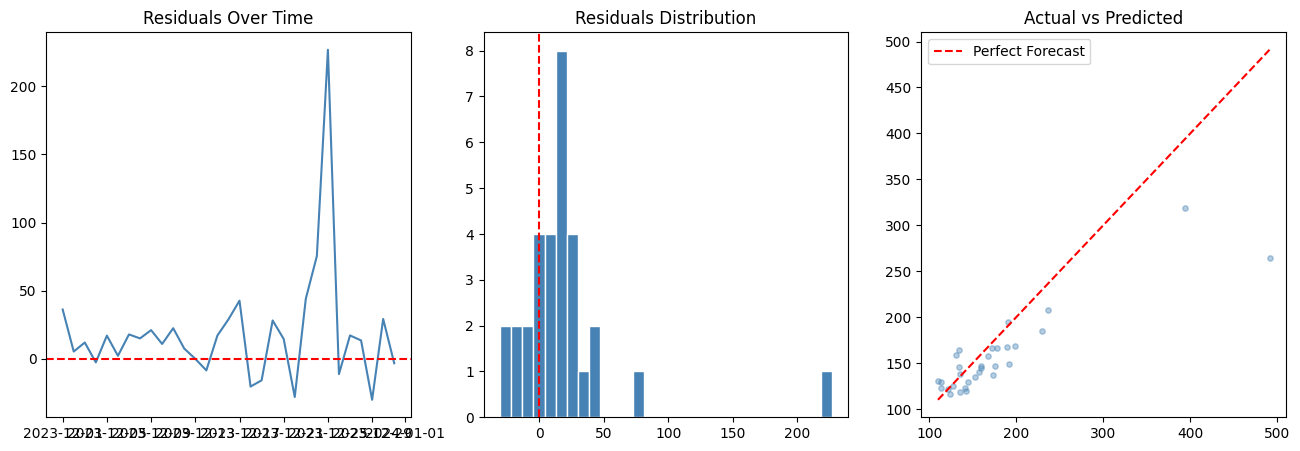

In [16]:
residuals = y_test.values - y_pred

plt.figure(figsize=(16,5))

# Residuals over time
plt.subplot(1,3,1)
plt.plot(y_test.index, residuals, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Over Time')

# Residual distribution
plt.subplot(1,3,2)
plt.hist(residuals, bins=30, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals Distribution')

# Actual vs Predicted
plt.subplot(1,3,3)
plt.scatter(y_test.values, y_pred, color='steelblue', alpha=0.4, s=15)

mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())

plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect Forecast')
plt.title('Actual vs Predicted')
plt.legend()

plt.show()

## **3. Feature Importance (All 3 New Columns Visible Here)**

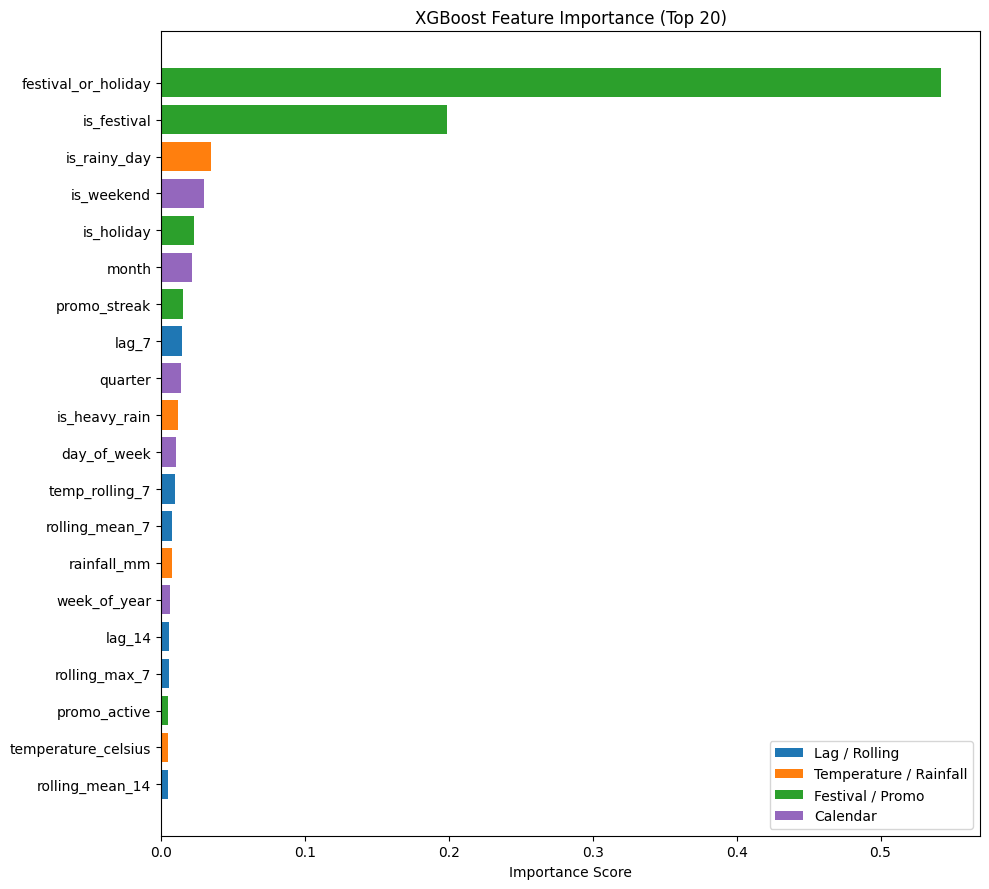

=== Rank of New Columns ===
#19  temperature_celsius       score=0.0049
#14  rainfall_mm               score=0.0073
# 2  is_festival               score=0.1987
#18  promo_active              score=0.0049
#34  is_hot_day                score=0.0003
# 3  is_rainy_day              score=0.0349
# 7  promo_streak              score=0.0149
# 1  festival_or_holiday       score=0.5420
#12  temp_rolling_7            score=0.0095
#10  is_heavy_rain             score=0.0117


In [ ]:
# Top 20 important features
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

colors = []

for col in feat_imp.index[::-1]:
    if 'lag' in col or 'rolling' in col:
        colors.append('#1f77b4')
    elif col in ['temperature_celsius', 'rainfall_mm', 'is_hot_day',
                 'is_rainy_day', 'is_heavy_rain', 'temp_rolling_7']:
        colors.append('#ff7f0e')
    elif col in ['is_festival', 'promo_active', 'promo_streak',
                 'festival_or_holiday', 'is_holiday']:
        colors.append('#2ca02c')
    else:
        colors.append('#9467bd')

plt.figure(figsize=(10,9))

plt.barh(
    feat_imp.index[::-1],
    feat_imp.values[::-1],
    color=colors
)

plt.title('XGBoost Feature Importance (Top 20)')
plt.xlabel('Importance Score')

# Legend
from matplotlib.patches import Patch

legend = [
    Patch(facecolor='#1f77b4', label='Lag / Rolling'),
    Patch(facecolor='#ff7f0e', label='Temperature / Rainfall'),
    Patch(facecolor='#2ca02c', label='Festival / Promo'),
    Patch(facecolor='#9467bd', label='Calendar')
]

plt.legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.savefig('reports/12_feature_importance.png')

plt.show()

# Rank of new columns
print("=== Rank of New Columns ===")

all_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

new_cols = [
    'temperature_celsius', 'rainfall_mm', 'is_festival',
    'promo_active', 'is_hot_day', 'is_rainy_day',
    'promo_streak', 'festival_or_holiday',
    'temp_rolling_7', 'is_heavy_rain'
]

for col in new_cols:
    if col in all_imp.index:
        rank = all_imp.index.get_loc(col) + 1
        score = all_imp[col]
        print(f"#{rank:2d}  {col:25s} score={score:.4f}")

## **4. Full Forecast Visualization**

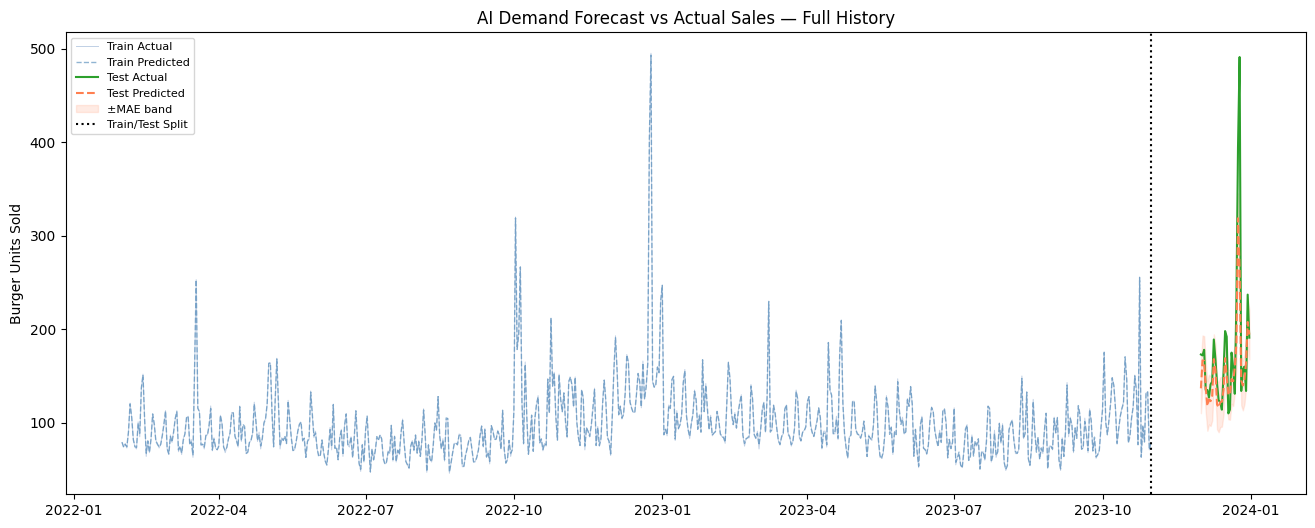

In [19]:
# Train prediction
train_preds = best_model.predict(X_train)

plt.figure(figsize=(16,6))

# Train actual
plt.plot(y_train.index, y_train.values,color='lightsteelblue',linewidth=0.7,alpha=0.8,label='Train Actual')

# Train predicted
plt.plot(y_train.index, train_preds,color='steelblue',linestyle='--',linewidth=1, alpha=0.6,label='Train Predicted')

# Test actual
plt.plot(y_test.index, y_test.values, color='#2ca02c', linewidth=1.5, label='Test Actual')

# Test predicted
plt.plot(y_test.index, y_pred, color='coral', linestyle='--', linewidth=1.5, label='Test Predicted')

# Error band
plt.fill_between( y_test.index, y_pred - mae, y_pred + mae, color='coral', alpha=0.15, label='±MAE band')

# Split line
plt.axvline(y_train.index.max(),color='black',linestyle=':',linewidth=1.5,label='Train/Test Split')

plt.title('AI Demand Forecast vs Actual Sales — Full History')
plt.ylabel('Burger Units Sold')
plt.legend(loc='upper left', fontsize=8)

plt.show()

## **5. 30-Day Future Forecast**

In [21]:
# Forecast days
FORECAST_DAYS = 30

# Future dates
last_date = df.dropna().index.max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1),
                             periods=FORECAST_DAYS, freq='D')

# Empty future events
FUTURE_FESTIVALS = pd.to_datetime([])
FUTURE_HOLIDAYS = pd.to_datetime([])
FUTURE_PROMOS = pd.to_datetime([])

# Base data
forecast_df = df.dropna().copy()
future_preds = []

# Monthly values
MONTHLY_TEMP = {
    1:21, 2:23.5, 3:26.5, 4:28, 5:27.5, 6:24,
    7:22.5, 8:22.5, 9:23, 10:23, 11:21.5, 12:20
}

MONTHLY_RAIN = {
    1:0.2, 2:0.3, 3:0.5, 4:1.5, 5:3.5, 6:7,
    7:9.5, 8:8, 9:8.5, 10:7, 11:3, 12:0.5
}

# Forecast loop
for d in future_dates:

    row = pd.DataFrame({
        'sales': [np.nan],
        'is_weekend': [int(d.dayofweek >= 5)],
        'is_holiday': [int(d in FUTURE_HOLIDAYS)],
        'is_festival': [int(d in FUTURE_FESTIVALS)],
        'promo_active': [int(d in FUTURE_PROMOS)],
        'temperature_celsius': [round(MONTHLY_TEMP[d.month] + np.random.normal(0,1),1)],
        'rainfall_mm': [round(max(0, np.random.exponential(MONTHLY_RAIN[d.month])),1)],
        'item': ['Burger']
    }, index=[d])

    # Add row
    temp = pd.concat([forecast_df, row])

    # Features
    temp = add_calendar_features(temp)
    temp = add_lag_features(temp)
    temp = add_rolling_features(temp)
    temp = add_external_features(temp)

    # Predict
    x = temp.loc[[d], X_train.columns]
    pred = best_model.predict(x)[0]

    # Save
    future_preds.append({
        'date': d,
        'predicted_sales': round(pred)
    })

    forecast_df.loc[d, 'sales'] = pred

# Final output
future_df = pd.DataFrame(future_preds).set_index('date')

print("=== 30-Day Demand Forecast ===")
print(future_df.to_string())

=== 30-Day Demand Forecast ===
            predicted_sales
date                       
2024-01-01              107
2024-01-02               88
2024-01-03               87
2024-01-04               89
2024-01-05              100
2024-01-06              135
2024-01-07              136
2024-01-08               90
2024-01-09               84
2024-01-10               94
2024-01-11               93
2024-01-12               97
2024-01-13              130
2024-01-14              130
2024-01-15               94
2024-01-16               93
2024-01-17               91
2024-01-18               93
2024-01-19              102
2024-01-20              130
2024-01-21              123
2024-01-22               93
2024-01-23               90
2024-01-24               93
2024-01-25               95
2024-01-26              102
2024-01-27              122
2024-01-28              114
2024-01-29               88
2024-01-30               88


C:\Users\Admin\AppData\Local\Temp\ipykernel_32628\2697413815.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.dropna()['sales'].last('90D')


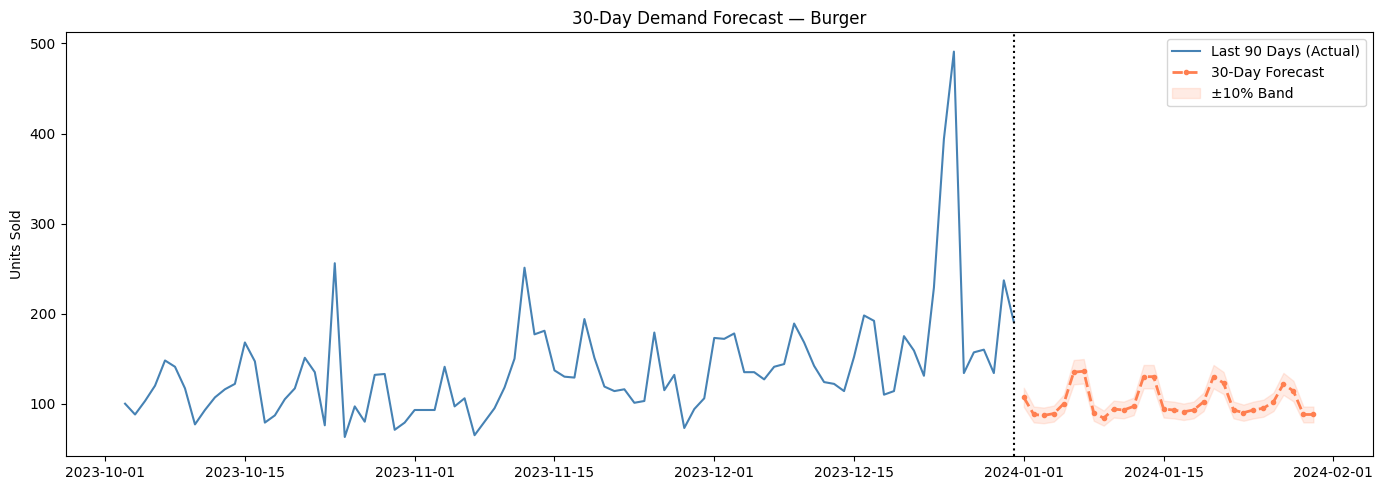

In [22]:
# Last 90 days sales
recent = df.dropna()['sales'].last('90D')

plt.figure(figsize=(14,5))

# Actual sales
plt.plot(
    recent.index,
    recent.values,
    color='steelblue',
    linewidth=1.5,
    label='Last 90 Days (Actual)'
)

# Forecast sales
plt.plot(
    future_df.index,
    future_df['predicted_sales'],
    color='coral',
    linestyle='--',
    marker='o',
    markersize=3,
    linewidth=2,
    label='30-Day Forecast'
)

# Forecast band
plt.fill_between(
    future_df.index,
    future_df['predicted_sales'] * 0.90,
    future_df['predicted_sales'] * 1.10,
    color='coral',
    alpha=0.15,
    label='±10% Band'
)

# Split line
plt.axvline(recent.index.max(), color='black', linestyle=':')

plt.title('30-Day Demand Forecast — Burger')
plt.ylabel('Units Sold')
plt.legend()

plt.tight_layout()
plt.savefig('reports/14_future_forecast.png')

plt.show()

## **6. Business Intelligence Report**

In [ ]:
avg = future_df['predicted_sales'].mean()

peak = future_df['predicted_sales'].idxmax()
low = future_df['predicted_sales'].idxmin()

wknd = future_df[future_df.index.dayofweek >= 5]['predicted_sales'].mean()
wkdy = future_df[future_df.index.dayofweek < 5]['predicted_sales'].mean()

premium = ((wknd / wkdy) - 1) * 100

# Print report
print("=" * 58)
print("   BUSINESS INTELLIGENCE REPORT — BURGER DEMAND")
print("=" * 58)

print(f"Forecast Period   : {future_df.index.min().date()} to {future_df.index.max().date()}")
print(f"Avg Daily Demand  : {avg:.0f} burgers/day")

print(f"Peak Day          : {peak.date()} ({future_df.loc[peak,'predicted_sales']:.0f} units)")
print(f"Lowest Day        : {low.date()} ({future_df.loc[low,'predicted_sales']:.0f} units)")

print(f"Weekend Avg       : {wknd:.0f} units/day")
print(f"Weekday Avg       : {wkdy:.0f} units/day")
print(f"Weekend Premium   : +{premium:.1f}%")

print("-" * 58)

print(f"Model Accuracy    : MAE={mae:.1f} | MAPE={mape:.1f}%")
print(f"Explained Var.    : R²={r2:.3f}")

print("-" * 58)

print("Inventory Recommendation:")
print(f"Order {avg + mae:.0f} patties/day")

print("Weather Insight:")
print("Increase Salad orders on hot days")
print("Reduce orders on heavy rain days")
print("Promo Insight:")
print("Run promos on low-demand weekdays")

print("=" * 58)

   BUSINESS INTELLIGENCE REPORT — BURGER DEMAND
Forecast Period   : 2024-01-01 to 2024-01-30
Avg Daily Demand  : 102 burgers/day
Peak Day          : 2024-01-07 (136 units)
Lowest Day        : 2024-01-09 (84 units)
Weekend Avg       : 128 units/day
Weekday Avg       : 93 units/day
Weekend Premium   : +36.8%
----------------------------------------------------------
Model Accuracy    : MAE=26.6 | MAPE=12.7%
Explained Var.    : R²=0.627
----------------------------------------------------------
Inventory Recommendation:
Order 129 patties/day
Weather Insight:
Increase Salad orders on hot days
Reduce orders on heavy rain days
Promo Insight:
Run promos on low-demand weekdays
